# GNN Pre-Training
Pre-trains the GNN encoder on synthetic 6G network topology data using a dummy supervised loss.

In [3]:
import torch
print(f"Is CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")

Is CUDA available: False
CUDA version: None


In [4]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
import torch.nn.functional as F
import numpy as np
import yaml
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader
from models.gnn import GNNModel
from utils.graph_builder import build_network_graph

In [5]:
with open('../configs/config.yaml') as f:
    config = yaml.safe_load(f)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print('Config:', config)

Using device: cpu
Config: {'network': {'num_base_stations': 10, 'num_users': 30, 'area_size': 1000, 'frequency_ghz': 28, 'max_bandwidth_mhz': 400}, 'training': {'episodes': 500, 'lr': 0.001, 'gamma': 0.99, 'batch_size': 64}}


## Generate Synthetic Dataset

In [6]:
def generate_dataset(config, num_samples=200):
    net = config['network']
    graphs = []
    for _ in range(num_samples):
        bs_pos = np.random.uniform(0, net['area_size'], (net['num_base_stations'], 2))
        user_pos = np.random.uniform(0, net['area_size'], (net['num_users'], 2))
        g = build_network_graph(bs_pos, user_pos)
        g.y = torch.rand(g.num_nodes, 1) 
        graphs.append(g)
    return graphs

dataset = generate_dataset(config)
loader = DataLoader(dataset, batch_size=16, shuffle=True)
print(f'Dataset: {len(dataset)} graphs | Batches per epoch: {len(loader)}')

Dataset: 200 graphs | Batches per epoch: 13


## Build Model

In [7]:
model = GNNModel(in_channels=3, hidden_channels=64, out_channels=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=config['training']['lr'])
print(model)

GNNModel(
  (conv1): GCNConv(3, 64)
  (conv2): GATConv(64, 64, heads=4)
  (conv3): GCNConv(64, 32)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)


## Training Loop

In [8]:
EPOCHS = 50
epoch_losses = []

model.train()
for epoch in range(1, EPOCHS + 1):
    total_loss = 0.0
    for batch in loader:
        batch = batch.to(device)
        out = model(batch)                          # (N, 32)
        loss = F.mse_loss(out[:, :1], batch.y)     # dummy supervised loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    epoch_losses.append(avg_loss)
    if epoch % 10 == 0:
        print(f'Epoch {epoch:03d} | Loss: {avg_loss:.4f}')

print('Training complete.')

Epoch 010 | Loss: 0.0924
Epoch 020 | Loss: 0.0895
Epoch 030 | Loss: 0.0882
Epoch 040 | Loss: 0.0878
Epoch 050 | Loss: 0.0866
Training complete.


## Loss Curve

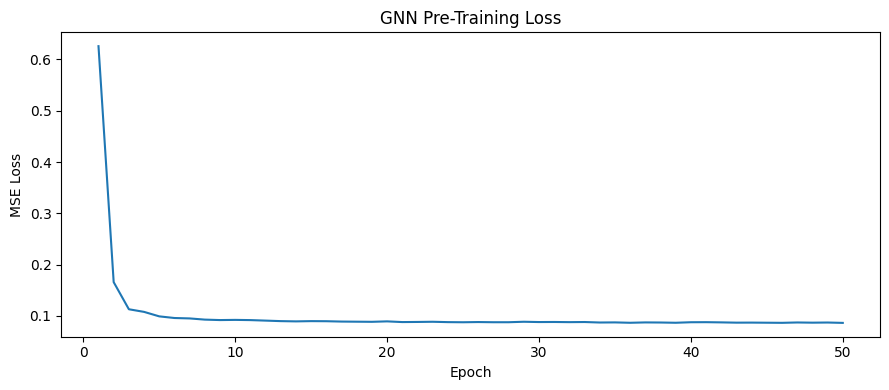

In [9]:
plt.figure(figsize=(9, 4))
plt.plot(range(1, EPOCHS + 1), epoch_losses)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('GNN Pre-Training Loss')
plt.tight_layout()
plt.show()

## Save Model

In [10]:
save_path = '../results/gnn_pretrained.pt'
os.makedirs('../results', exist_ok=True)
torch.save(model.state_dict(), save_path)
print(f'GNN saved to {save_path}')

GNN saved to ../results/gnn_pretrained.pt
